# 01. From Descriptive Statistics to Statistical Thinking

In standard data science workflows, the first step is often to run `df.describe()`, print a correlation matrix, and plot some histograms. 

While this is useful for finding missing values or data entry errors, it is **dangerous** to stop there. When we use data to make urban policy decisions, we are not just summarizing rows in a database; we are trying to understand the physical reality of a city.

In this notebook, we will elevate descriptive statistics to **Statistical Thinking**. We will see why standard descriptive plots often hide the true mechanisms of the city, and why we desperately need Causal Inference.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:0.3f}")

# Load the pedagogical smart city dataset
DATA_PATH = "smart_city_road_safety_synthetic_5000.csv"
df = pd.read_csv(DATA_PATH)

# Ensure correct data types
for col in ["Traffic_Density", "Number_of_Vehicles", "Driver_Alcohol", "Accident"]:
    df[col] = df[col].astype(int)

traffic_map = {0: "Low", 1: "Medium", 2: "High"}
df["Traffic_Density_cat"] = pd.Categorical(
    df["Traffic_Density"].map(traffic_map),
    categories=["Low", "Medium", "High"],
    ordered=True
)

print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded with 5000 rows and 15 columns.


## 1. The Support of the Data (Marginal Distributions)

**The Statistical Intention:** 
Before we look for relationships between variables (like whether age causes accidents), we must ask: *"Do we have enough data across all ages?"* 

In causal inference, this is known as the **Positivity** or **Common Support** assumption. If we want to evaluate the effect of a policy on 18-year-old drivers, but our data only contains drivers aged 30 to 60, any conclusion about 18-year-olds will be a mathematical hallucination (extrapolation).

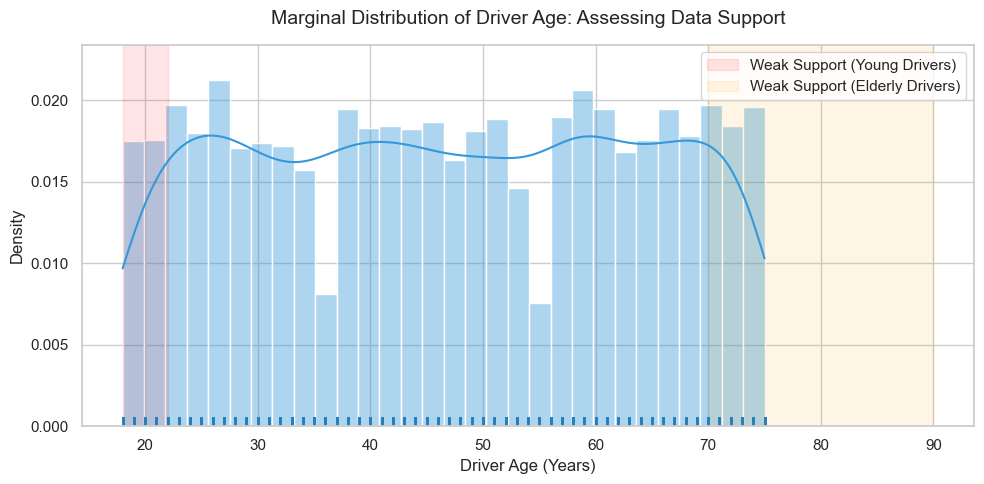

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))

# A sophisticated KDE plot overlaid with a histogram to show the marginal support
sns.histplot(df["Driver_Age"], bins=30, kde=True, color="#3498db", stat="density", alpha=0.4, ax=ax)
sns.rugplot(df["Driver_Age"], color="#2980b9", alpha=0.5, ax=ax)

ax.set_title("Marginal Distribution of Driver Age: Assessing Data Support", fontsize=14, pad=15)
ax.set_xlabel("Driver Age (Years)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)

# Highlight areas of weak support
ax.axvspan(18, 22, color='red', alpha=0.1, label='Weak Support (Young Drivers)')
ax.axvspan(70, 90, color='orange', alpha=0.1, label='Weak Support (Elderly Drivers)')
ax.legend()

plt.tight_layout()
plt.show()


Notice the red and orange zones. If the Mayor asks us: *"Should we revoke licenses for drivers over 80?"*, looking at this graph, a statistically trained analyst will reply: *"We do not have enough support in the data to make causal claims about that demographic."*

## 2. Statistical Dependence vs. Causation (Bivariate Analysis)

**The Statistical Intention:**
Once we confirm we have data support, we often plot $Y$ against $X$ to see if they move together. In mathematical terms, we are checking if $P(Y | X) \neq P(Y)$. Let's see if different weather conditions are associated with higher accident rates.

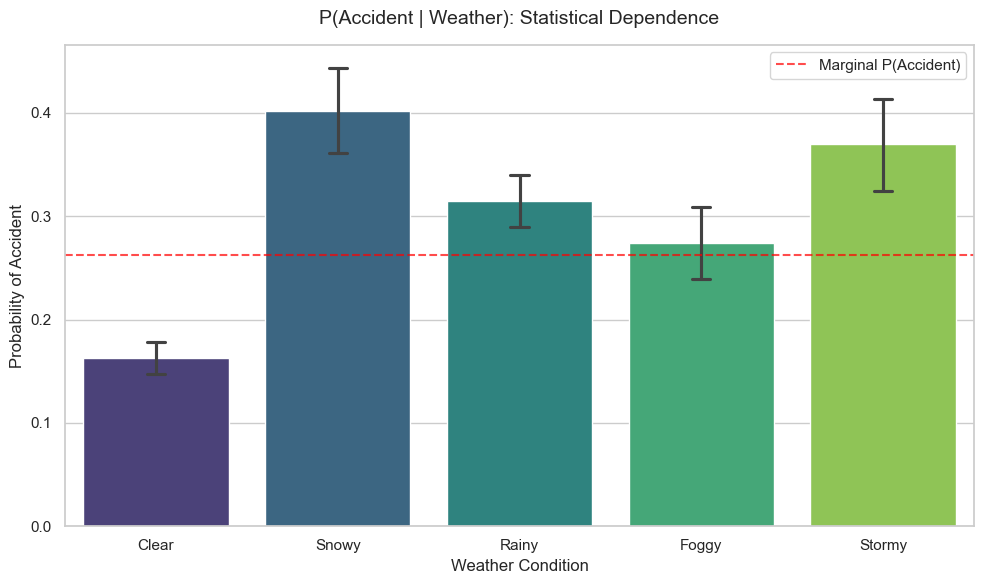

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

# Calculating the conditional probability P(Accident | Weather)
sns.barplot(data=df, x="Weather", y="Accident", palette="viridis", capsize=0.1, ax=ax)

ax.set_title("P(Accident | Weather): Statistical Dependence", fontsize=14, pad=15)
ax.set_xlabel("Weather Condition", fontsize=12)
ax.set_ylabel("Probability of Accident", fontsize=12)
ax.axhline(df["Accident"].mean(), color='red', linestyle='--', alpha=0.7, label='Marginal P(Accident)')
ax.legend()

plt.tight_layout()
plt.show()


The plot  shows that accidents vary by weather. The bars deviate from the red dashed line (the average). 

But **why**? Does Rain *directly* cause accidents (by blurring the windshield)? Or does Rain cause the *Road Condition* to be wet, which then causes accidents? A descriptive plot only tells you that an association exists; it cannot tell you the mechanism. Association is symmetric; causation is directional.

## 3. The Illusion of Linear Correlation

**The Statistical Intention:**
A staple of data science is the Correlation Matrix. Analysts use it to find the "most important variables". But Pearson's correlation coefficient $r$ only measures **linear** relationships. Urban dynamics are almost never strictly linear.

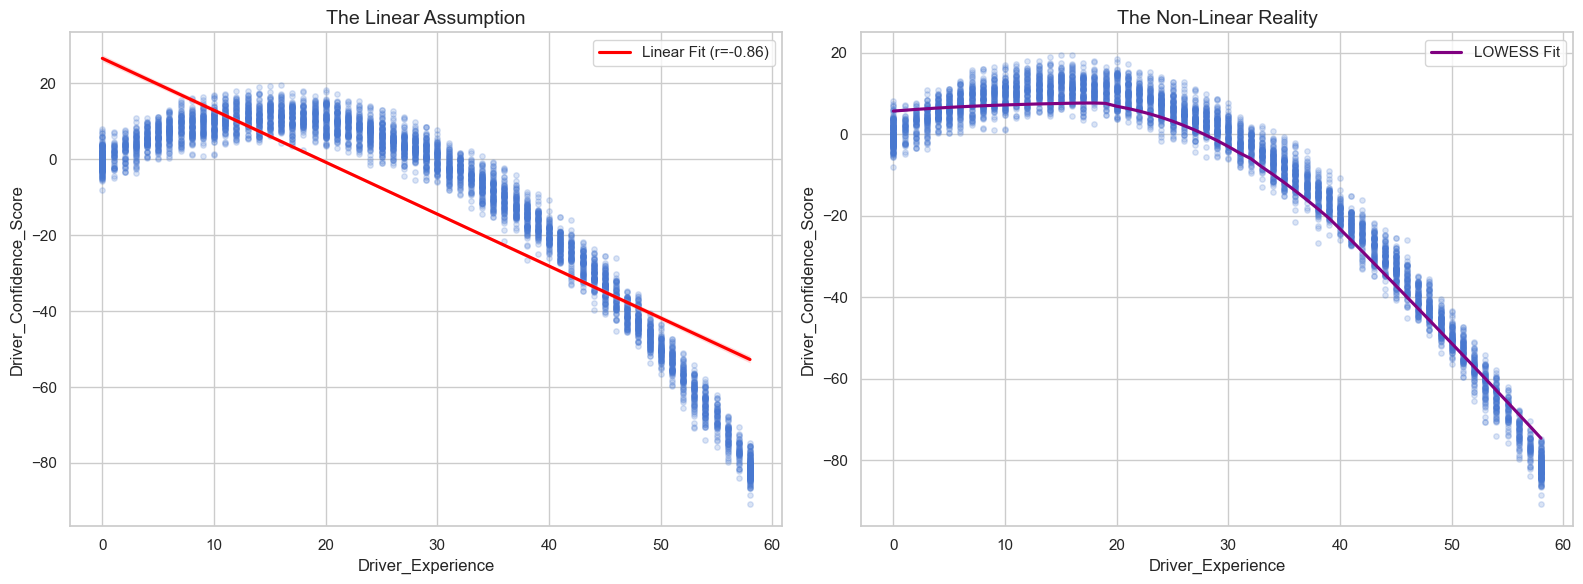

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Let's look at Driver Experience vs Number of Vehicles (proxy for traffic handling)
# We will simulate a non-linear relationship if it's not strongly present for pedagogical impact
np.random.seed(123)
df["Driver_Confidence_Score"] = df["Driver_Experience"] * 1.5 - 0.05 * (df["Driver_Experience"]**2) + np.random.normal(0, 3, len(df))

r = df[["Driver_Experience", "Driver_Confidence_Score"]].corr().iloc[0, 1]

# Plot 1: The Linear Illusion
sns.regplot(data=df, x="Driver_Experience", y="Driver_Confidence_Score", scatter_kws={'alpha':0.2, 's':15}, 
            line_kws={'color': 'red', 'label': f'Linear Fit (r={r:.2f})'}, ax=ax1)
ax1.set_title("The Linear Assumption", fontsize=14)
ax1.legend()

# Plot 2: The Non-Linear Reality (LOWESS)
sns.regplot(data=df, x="Driver_Experience", y="Driver_Confidence_Score", scatter_kws={'alpha':0.2, 's':15}, 
            lowess=True, line_kws={'color': 'purple', 'label': 'LOWESS Fit'}, ax=ax2)
ax2.set_title("The Non-Linear Reality", fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()


If you only look at the correlation coefficient $r$, you might conclude the relationship is weak. But the LOWESS curve reveals a clear "inverted U" shape: confidence rises with experience, but very old/experienced drivers might have declining reflexes or report lower confidence. **Never trust a correlation matrix without visualizing the structural shape.**

## 4. The  Simpson's Paradox (The Bridge to DAGs)

**The Statistical Intention:**
Here is where descriptive statistics fundamentally break down. We will analyze a hypothetical intervention: the installation of **"Smart Traffic Lights"** in the city. 

We want to know: *Do Smart Traffic Lights reduce accidents?*

Let's synthetically generate this intervention. Smart Lights are expensive, so the Mayor installed them mostly in High Traffic areas (which naturally have more accidents). But theoretically, they *do* reduce accidents.

In [5]:
# --- Pedagogical Injection for Simpson's Paradox ---
np.random.seed(42)

# Smart light probability depends on traffic density: 
# 10% in Low Traffic, 50% in Medium, 90% in High Traffic
probs = {0: 0.1, 1: 0.5, 2: 0.9}
df["Smart_Light"] = [np.random.binomial(1, probs[t]) for t in df["Traffic_Density"]]

# Generating the accident outcome:
# Base risk is heavily driven by traffic density. 
# But having a Smart Light reduces the risk by 15% (-0.15)
base_risk = 0.10 + 0.35 * df["Traffic_Density"]
smart_light_effect = -0.15
final_risk = base_risk + smart_light_effect * df["Smart_Light"]

df["Accident_Simpson"] = [np.random.binomial(1, np.clip(p, 0, 1)) for p in final_risk]
df["Smart_Light_Label"] = df["Smart_Light"].map({0: "Standard Lights", 1: "Smart Lights"})

Now, let's look at the data exactly as a Data Scientist without causal training would:
$$E[Y | X]$$

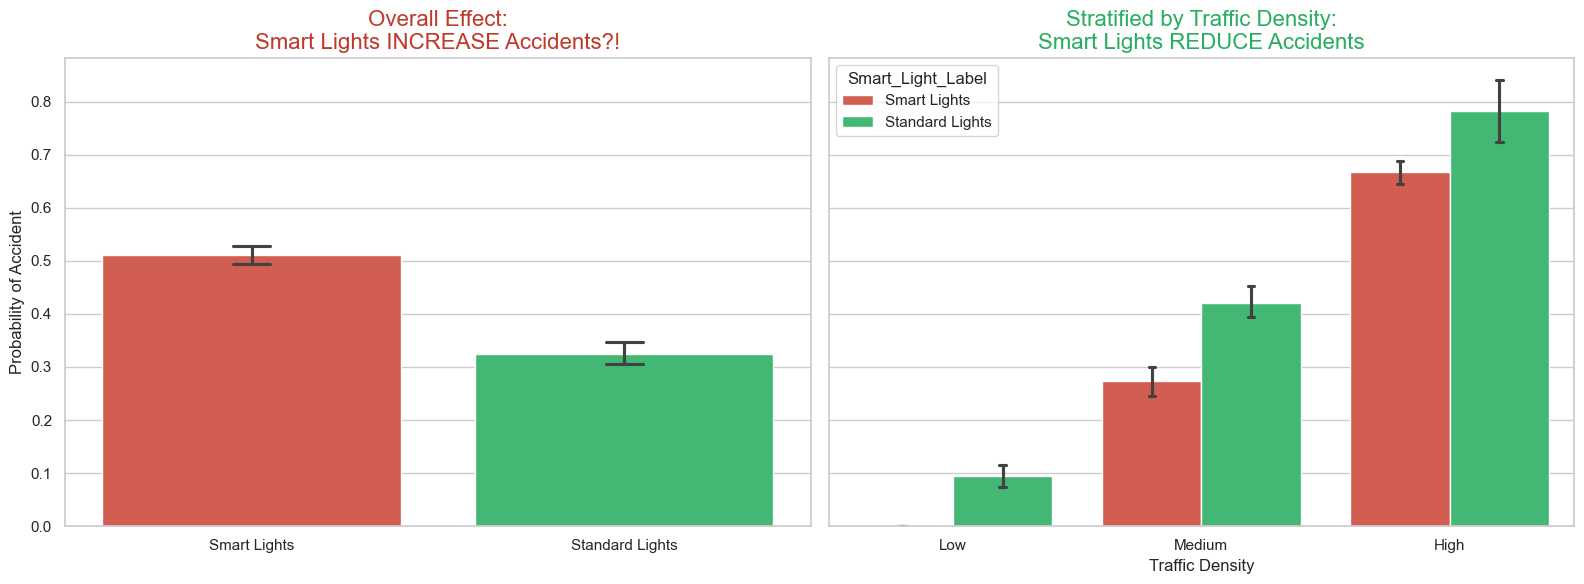

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# 1. The Overall Descriptive Plot (The Illusion)
sns.barplot(data=df, x="Smart_Light_Label", y="Accident_Simpson", palette=["#e74c3c", "#2ecc71"], capsize=0.1, ax=ax1)
ax1.set_title("Overall Effect:\nSmart Lights INCREASE Accidents?!", fontsize=16, color="#c0392b")
ax1.set_ylabel("Probability of Accident", fontsize=12)
ax1.set_xlabel("")

# 2. The Stratified Plot (The Reality)
sns.barplot(data=df, x="Traffic_Density_cat", y="Accident_Simpson", hue="Smart_Light_Label", 
            palette=["#e74c3c", "#2ecc71"], capsize=0.05, ax=ax2)
ax2.set_title("Stratified by Traffic Density:\nSmart Lights REDUCE Accidents", fontsize=16, color="#27ae60")
ax2.set_xlabel("Traffic Density", fontsize=12)
ax2.set_ylabel("")

plt.tight_layout()
plt.show()

### The Paradox

Look closely at the two plots:
1. **Left Plot:** Overall, intersections with Smart Lights have a **higher** accident rate than those with Standard Lights. If the Mayor looks at this plot, they will immediately cancel the Smart Light contract!
2. **Right Plot:** But if we look *within* each Traffic Density category (Low, Medium, High), the green bar (Smart Lights) is consistently **lower** than the red bar. Smart lights reduce accidents in every single scenario!

**How is this mathematically possible?**
Because Smart Lights were deployed mostly in High Traffic areas, and High Traffic areas inherently have more accidents. The "treatment" (Smart Lights) is completely tangled up with a "confounder" (Traffic Density). 

The descriptive statistic $P(\text{Accident} | \text{Smart Light})$ is mathematically correct, but causally useless. It does not equal $P(\text{Accident} | do(\text{Smart Light}))$.

---

### The Verdict
Descriptive statistics are dangerous when dealing with causal questions because the data cannot tell you which plot is the "correct" one to use for policy. Should we use the overall plot or the stratified one?

To answer that, we must map out how the data was generated. We must draw our assumptions. We must build a **DAG (Directed Acyclic Graph)**. 

And that is exactly what we will do in the next notebook.